# 🎭 AvatarForcing — End-to-End RunPod RTX 5090 Notebook
One-Step Streaming Talking Avatars — run all cells top to bottom.

## 🖥️ Step 0 — GPU Check

In [1]:
import subprocess, sys, os

def run(cmd, check=True, **kwargs):
    print(f'>>> {cmd}')
    result = subprocess.run(cmd, shell=True, text=True, **kwargs)
    if check and result.returncode != 0:
        raise RuntimeError(f'Command failed (exit {result.returncode}): {cmd}')
    return result

run('nvidia-smi')
run('nvcc --version')

>>> nvidia-smi
Wed May  6 17:33:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:B7:00.0 Off |                    0 |
| N/A   44C    P0             73W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+--------------------------------

CompletedProcess(args='nvcc --version', returncode=0)

## 🐍 Step 1 — Find or Install Conda

In [2]:
import shutil, os, subprocess

CONDA_SEARCH_PATHS = [
    '/opt/conda/bin/conda',
    '/root/miniconda3/bin/conda',
    '/root/anaconda3/bin/conda',
    '/usr/local/conda/bin/conda',
]

CONDA_BIN = shutil.which('conda')
if CONDA_BIN is None:
    for p in CONDA_SEARCH_PATHS:
        if os.path.isfile(p):
            CONDA_BIN = p
            break

if CONDA_BIN:
    print(f'✅ Found conda at: {CONDA_BIN}')
    subprocess.run(f'{CONDA_BIN} --version', shell=True)
else:
    print('Installing Miniconda...')
    for c in [
        'curl -fsSL https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -o /tmp/miniconda.sh',
        'bash /tmp/miniconda.sh -b -p /root/miniconda3',
    ]:
        run(c)
    CONDA_BIN = '/root/miniconda3/bin/conda'

CONDA_DIR = os.path.dirname(os.path.dirname(CONDA_BIN))
print(f'CONDA_DIR = {CONDA_DIR}')

Installing Miniconda...
>>> curl -fsSL https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -o /tmp/miniconda.sh
>>> bash /tmp/miniconda.sh -b -p /root/miniconda3
PREFIX=/root/miniconda3
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
CONDA_DIR = /root/miniconda3


## 📁 Step 2 — Clone Repository

In [ ]:
REPO_DIR = '/workspace/AvatarForcing-inference-v1'

if not os.path.isdir(REPO_DIR):
    run(f'git clone https://github.com/MoshiHead/AvatarForcing-inference-v1.git {REPO_DIR}')
else:
    print(f'✅ Repo already exists at {REPO_DIR}')

os.chdir(REPO_DIR)
run('ls -la')

>>> git clone https://github.com/KlingAIResearch/AvatarForcing.git /workspace/AvatarForcing


Cloning into '/workspace/AvatarForcing'...


>>> ls -la
total 56
drwxr-xr-x 9 root root  4096 May  6 17:33 .
drwxr-xr-x 4 root root   107 May  6 17:33 ..
-rw-r--r-- 1 root root  6148 May  6 17:33 .DS_Store
drwxr-xr-x 8 root root  4096 May  6 17:33 .git
-rw-r--r-- 1 root root 12252 May  6 17:33 LICENSE.txt
-rw-r--r-- 1 root root  4641 May  6 17:33 README.md
drwxr-xr-x 2 root root    30 May  6 17:33 assets
drwxr-xr-x 2 root root    71 May  6 17:33 configs
-rw-r--r-- 1 root root  7515 May  6 17:33 environment.yml
drwxr-xr-x 2 root root    72 May  6 17:33 example
-rw-r--r-- 1 root root  7825 May  6 17:33 inference.py
drwxr-xr-x 2 root root    72 May  6 17:33 pipeline
drwxr-xr-x 2 root root   186 May  6 17:33 utils
drwxr-xr-x 7 root root  4096 May  6 17:33 wan


CompletedProcess(args='ls -la', returncode=0)

## 🌿 Step 3 — Patch environment.yml & Create Conda Env

**Three patches applied to `environment.yml` before creation:**
1. `defaults` → `conda-forge` — fixes `CondaToSNonInteractiveError`
2. Remove `torch / torchvision / torchaudio` pip lines — `+cu121` tag only exists on the PyTorch index, not PyPI
3. Remove `flash-attn` pip line — needs torch already installed to compile
4. Remove `nvidia-*` and `cuda-*` pip lines — CUDA packages also require special index
5. Remove `triton` pip line — depends on torch

All removed packages are installed correctly in **Step 5**.

In [4]:
# 3a — Accept Anaconda TOS
run(f'{CONDA_BIN} tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main', check=False)
run(f'{CONDA_BIN} tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r', check=False)
print('✅ TOS accepted.')

>>> /root/miniconda3/bin/conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
>>> /root/miniconda3/bin/conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
✅ TOS accepted.


In [5]:
import re, shutil as _sh

yml_path = f'{REPO_DIR}/environment.yml'
yml_bak  = f'{REPO_DIR}/environment.yml.bak'

# Always restore from original backup so re-running is idempotent
if os.path.exists(yml_bak):
    _sh.copy(yml_bak, yml_path)
    print('Restored original from backup.')
else:
    _sh.copy(yml_path, yml_bak)
    print(f'Backup saved: {yml_bak}')

with open(yml_path) as fh:
    content = fh.read()

# --- Patch 1: defaults → conda-forge ---
content = content.replace('  - defaults', '  - conda-forge')

# --- Patches 2-5: remove packages that need special index or pre-installed torch ---
# Pattern: match any pip list line containing these package prefixes
REMOVE_PREFIXES = [
    'flash.attn',   # needs torch to build
    'torch==',      # +cu121 not on PyPI
    'torchvision',  # +cu121 not on PyPI
    'torchaudio',   # +cu121 not on PyPI
    'torchmetrics', # depends on torch version
    'nvidia-',      # CUDA packages need torch index
    'cuda-',        # CUDA runtime packages
    'triton==',     # needs torch
    'pytorch-lightning', # depends on torch
]

removed = []
lines_out = []
for line in content.splitlines(keepends=True):
    stripped = line.strip().lstrip('-').strip()
    matched = any(stripped.lower().startswith(p.lower()) for p in REMOVE_PREFIXES)
    if matched:
        removed.append(stripped.split('==')[0])
    else:
        lines_out.append(line)

content = ''.join(lines_out)

with open(yml_path, 'w') as fh:
    fh.write(content)

print(f'✅ environment.yml patched — removed {len(removed)} problematic pip packages:')
for p in removed:
    print(f'   - {p}')

Backup saved: /workspace/AvatarForcing/environment.yml.bak
✅ environment.yml patched — removed 26 problematic pip packages:
   - cuda-bindings
   - cuda-pathfinder
   - nvidia-cublas-cu12
   - nvidia-cuda-cupti-cu12
   - nvidia-cuda-nvrtc-cu12
   - nvidia-cuda-runtime-cu12
   - nvidia-cudnn-cu12
   - nvidia-cufft-cu12
   - nvidia-cufile-cu12
   - nvidia-curand-cu12
   - nvidia-cusolver-cu12
   - nvidia-cusparse-cu12
   - nvidia-cusparselt-cu12
   - nvidia-ml-py
   - nvidia-nccl-cu12
   - nvidia-nvjitlink-cu12
   - nvidia-nvshmem-cu12
   - nvidia-nvtx-cu12
   - nvidia-pyindex
   - nvidia-tensorrt
   - pytorch-lightning
   - torch
   - torchaudio
   - torchmetrics
   - torchvision
   - triton


In [6]:
# 3c — Create conda env
result = subprocess.run(f'{CONDA_BIN} env list', shell=True, text=True, capture_output=True)
print(result.stdout)

if 'avatarforcing' in result.stdout:
    print("✅ Conda env 'avatarforcing' already exists. Skipping.")
else:
    print('Creating conda env (may take 10–20 min)...')
    run(f'{CONDA_BIN} env create -f {REPO_DIR}/environment.yml')
    print('✅ Conda env created!')


# conda environments:
#
# * -> active
# + -> frozen
base                     /root/miniconda3


Creating conda env (may take 10–20 min)...
>>> /root/miniconda3/bin/conda env create -f /workspace/AvatarForcing/environment.yml
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done

python-3.10.19       | 24.5 MB   |            |   0% 
libgcc-ng-11.2.0     | 5.3 MB    |            |   0% 

libstdcxx-ng-11.2.0  | 4.7 MB    |            |   0% 


openssl-3.0.18       | 4.5 MB    |            |   0% 



setuptools-80.9.0    | 1.4 MB    |            |   0% 




pip-25.2             | 1.1 MB    |            |   0% 





sqlite-3.50.2        | 1.1 MB    |            |   0% 






ld_impl_linux-64-2.4 | 672 KB    |            |   0% 







xz-5.6.4             | 567 KB    |            |   0% 








libgomp-11.2.0       | 474 KB    |            |   0% 









expat-2.7.1          | 18

Pip subprocess error:
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [6 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 35, in <module>
        File "/tmp/pip-install-7trxql6j/flash-attn_87e864ab7d7344b58172c4bd635e3e05/setup.py", line 21, in <module>
          import torch
      ModuleNotFoundError: No module named 'torch'
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


CondaEnvException: Pip failed




failed


RuntimeError: Command failed (exit 1): /root/miniconda3/bin/conda env create -f /workspace/AvatarForcing/environment.yml

In [8]:
# Helper: run a command inside the avatarforcing env
def run_in_env(cmd, **kwargs):
    return run(f'{CONDA_BIN} run -n avatarforcing --no-capture-output {cmd}', **kwargs)

run_in_env('python --version')
run_in_env('pip --version')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python --version
Python 3.10.19
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip --version
pip 25.2 from /root/miniconda3/envs/avatarforcing/lib/python3.10/site-packages/pip (python 3.10)


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip --version', returncode=0)

## 🔧 Step 4 — Install System Dependencies (FFmpeg)

In [7]:
run('apt-get update -qq && apt-get install -y ffmpeg libsm6 libxext6 -qq')
run('ffmpeg -version 2>&1 | head -3')

>>> apt-get update -qq && apt-get install -y ffmpeg libsm6 libxext6 -qq


debconf: delaying package configuration, since apt-utils is not installed


(Reading database ... 24135 files and directories currently installed.)
Preparing to unpack .../libatomic1_12.3.0-1ubuntu1~22.04.3_amd64.deb ...
Unpacking libatomic1:amd64 (12.3.0-1ubuntu1~22.04.3) over (12.3.0-1ubuntu1~22.04) ...
Preparing to unpack .../libubsan1_12.3.0-1ubuntu1~22.04.3_amd64.deb ...
Unpacking libubsan1:amd64 (12.3.0-1ubuntu1~22.04.3) over (12.3.0-1ubuntu1~22.04) ...
Preparing to unpack .../gcc-12-base_12.3.0-1ubuntu1~22.04.3_amd64.deb ...
Unpacking gcc-12-base:amd64 (12.3.0-1ubuntu1~22.04.3) over (12.3.0-1ubuntu1~22.04) ...
Setting up gcc-12-base:amd64 (12.3.0-1ubuntu1~22.04.3) ...
(Reading database ... 24135 files and directories currently installed.)
Preparing to unpack .../libstdc++6_12.3.0-1ubuntu1~22.04.3_amd64.deb ...
Unpacking libstdc++6:amd64 (12.3.0-1ubuntu1~22.04.3) over (12.3.0-1ubuntu1~22.04) ...
Setting up libstdc++6:amd64 (12.3.0-1ubuntu1~22.04.3) ...
(Reading database ... 24135 files and directories currently installed.)
Preparing to unpack .../0-libqu

CompletedProcess(args='ffmpeg -version 2>&1 | head -3', returncode=0)

## ⚡ Step 5 — Install PyTorch (cu126) + flash-attn for RTX 5090

RTX 5090 = Blackwell / SM_100.  
We install `cu126` PyTorch wheels (from the official PyTorch index),  
then install **flash-attn via a pre-built wheel** (seconds, not hours!).

| Component | Version |
|---|---|
| CUDA | 12.6 (cu126) |
| PyTorch | 2.6.0 |
| Python | 3.11 |
| flash-attn | 2.7.4 (pre-built binary) |

In [9]:
# 5a — Install PyTorch cu126 + torchvision + torchaudio
print('Installing PyTorch cu126 (torch 2.6.0)...')
run_in_env(
    'pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 '
    '--index-url https://download.pytorch.org/whl/cu126'
)
print('✅ PyTorch cu126 installed.')

Installing PyTorch cu126 (torch 2.6.0)...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu126
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 102.5 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 221.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 170.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 115.4 MB/s  0:00:0400:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 115.1 MB/s  0:00:03a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 116.9 MB/s  0:00:01a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 100.9 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 75.1 MB/s  0:00:02ta 0:00:01
     ━━━━━━━━━

✅ PyTorch cu126 installed.


In [10]:
# 5b — Install pytorch-lightning and torchmetrics (compatible with torch 2.6.0)
run_in_env('pip install pytorch-lightning torchmetrics -q')
print('✅ pytorch-lightning + torchmetrics installed.')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install pytorch-lightning torchmetrics -q


✅ pytorch-lightning + torchmetrics installed.


In [11]:
# 5c — Verify torch sees the GPU
run_in_env('python -c "import torch; print(torch.__version__, torch.version.cuda, torch.cuda.is_available(), torch.cuda.get_device_name(0))"')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python -c "import torch; print(torch.__version__, torch.version.cuda, torch.cuda.is_available(), torch.cuda.get_device_name(0))"
2.6.0+cu126 12.6 True NVIDIA A100-SXM4-80GB


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python -c "import torch; print(torch.__version__, torch.version.cuda, torch.cuda.is_available(), torch.cuda.get_device_name(0))"', returncode=0)

In [12]:
# 5d — Install flash-attn via pre-built wheel (auto-detects correct wheel)
import subprocess, sys, re

# Detect actual versions INSIDE the conda env
def query_env(py_expr):
    cmd = f'{CONDA_BIN} run -n avatarforcing --no-capture-output python -c "{py_expr}"'
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    return r.stdout.strip()

py_ver  = query_env('import sys; print(f"cp{sys.version_info.major}{sys.version_info.minor}")')  # e.g. cp311
torch_v = query_env('import torch; print(torch.__version__.split("+")[0])')                      # e.g. 2.6.0
cuda_v  = query_env('import torch; print(torch.version.cuda)')                                   # e.g. 12.6

torch_short = re.sub(r'(\d+\.\d+)\..*', r'\1', torch_v)      # 2.6.0 -> 2.6
torch_tag   = torch_short.replace('.', '')                      # 2.6   -> 26
cuda_tag    = cuda_v.replace('.', '')                           # 12.6  -> 126

print(f'Detected → Python: {py_ver} | Torch: {torch_v} ({torch_short}) | CUDA: {cuda_v}')
print(f'Tags     → cu{cuda_tag}  torch{torch_tag}  {py_ver}')

# Try cxx11abiFALSE first, then TRUE as fallback
BASE = 'https://github.com/Dao-AILab/flash-attention/releases/download/v2.7.4'
candidates = [
    f'{BASE}/flash_attn-2.7.4+cu{cuda_tag}torch{torch_tag}cxx11abiFALSE-{py_ver}-{py_ver}-linux_x86_64.whl',
    f'{BASE}/flash_attn-2.7.4+cu{cuda_tag}torch{torch_tag}cxx11abiTRUE-{py_ver}-{py_ver}-linux_x86_64.whl',
]

import urllib.request
chosen = None
for url in candidates:
    try:
        req = urllib.request.Request(url, method='HEAD')
        urllib.request.urlopen(req, timeout=10)
        chosen = url
        print(f'✅ Wheel found: {url.split("/")[-1]}')
        break
    except Exception:
        print(f'✗  Not found:  {url.split("/")[-1]}')

if chosen:
    print('\nInstalling (should be < 1 min)...')
    run_in_env(f'pip install "{chosen}" --no-build-isolation -q')
    print('✅ flash-attn installed!')
else:
    print('\n⚠️  No pre-built wheel matched. Check available wheels at:')
    print('   https://github.com/Dao-AILab/flash-attention/releases/tag/v2.7.4')
    print(f'   Look for: cu{cuda_tag}  torch{torch_tag}  {py_ver}  linux_x86_64')
    print('\nFalling back to source build (will take 60-120 min)...')
    run_in_env('pip install flash-attn --no-build-isolation')
    print('✅ flash-attn built from source.')

Detected → Python:  | Torch:  () | CUDA: 12.6
Tags     → cu126  torch  
✗  Not found:  flash_attn-2.7.4+cu126torchcxx11abiFALSE---linux_x86_64.whl
✗  Not found:  flash_attn-2.7.4+cu126torchcxx11abiTRUE---linux_x86_64.whl

⚠️  No pre-built wheel matched. Check available wheels at:
   https://github.com/Dao-AILab/flash-attention/releases/tag/v2.7.4
   Look for: cu126  torch    linux_x86_64

Falling back to source build (will take 60-120 min)...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install flash-attn --no-build-isolation
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 39.3 MB/s  0:00:00 eta 0:00:01
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  DEPRECATION: Building 'flash-attn' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'flash-attn'. Discussion can be found at https://github.com/pypa/pip/issues/6334


  Created wheel for flash-attn: filename=flash_attn-2.8.3-cp310-cp310-linux_x86_64.whl size=256007328 sha256=0a6d13b01818ff2758bdb9dc87362c72016303a7c26dd4f497e9e82006744209
  Stored in directory: /root/.cache/pip/wheels/f5/05/1e/a6726e9eee2e7ee6151dbfed113e89d220dd3964ba617ab32d
Successfully built flash-attn
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [flash-attn]2 [flash-attn]


✅ flash-attn built from source.


In [13]:
# 5e — Final environment verification
run_in_env('python -c "import torch, flash_attn; print(\'torch:\', torch.__version__); print(\'cuda:\', torch.version.cuda); print(\'flash_attn:\', flash_attn.__version__)"')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python -c "import torch, flash_attn; print('torch:', torch.__version__); print('cuda:', torch.version.cuda); print('flash_attn:', flash_attn.__version__)"
torch: 2.6.0+cu126
cuda: 12.6
flash_attn: 2.8.3


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python -c "import torch, flash_attn; print(\'torch:\', torch.__version__); print(\'cuda:\', torch.version.cuda); print(\'flash_attn:\', flash_attn.__version__)"', returncode=0)

## 📦 Step 6 — Install huggingface_hub & (Optional) Login

In [14]:
run_in_env("pip install -q 'huggingface_hub[cli]'")

HF_TOKEN = ''  # paste token if needed; all 3 models are public
if HF_TOKEN:
    os.environ['HF_TOKEN'] = HF_TOKEN
    run_in_env(f'huggingface-cli login --token {HF_TOKEN}')
else:
    print('ℹ️  No HF token — public access is fine.')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install -q 'huggingface_hub[cli]'


ℹ️  No HF token — public access is fine.


## ⬇️ Step 7 — Download Models

| Model | Repo | Size |
|---|---|---|
| Wan2.1-T2V-1.3B | `Wan-AI/Wan2.1-T2V-1.3B` | ~5 GB |
| wav2vec2-base-960h | `facebook/wav2vec2-base-960h` | ~360 MB |
| AvatarForcing | `lycui/AvatarForcing` | ~2 GB |

In [15]:
WAN_DIR     = f'{REPO_DIR}/wan_models/Wan2.1-T2V-1.3B'
WAV2VEC_DIR = f'{REPO_DIR}/wan_models/wav2vec2-base-960h'
CKPT_DIR    = f'{REPO_DIR}/checkpoints'
for d in [WAN_DIR, WAV2VEC_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)
print('Directories ready.')

Directories ready.


In [16]:
if not any(os.scandir(WAN_DIR)):
    run_in_env(f'hf download Wan-AI/Wan2.1-T2V-1.3B --local-dir {WAN_DIR}')
else:
    print(f'✅ Wan model already at {WAN_DIR}')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output hf download Wan-AI/Wan2.1-T2V-1.3B --local-dir /workspace/AvatarForcing/wan_models/Wan2.1-T2V-1.3B


Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Still waiting to acquire lock on /workspace/AvatarForcing/wan_models/Wan2.1-T2V-1.3B/.cache/huggingface/.gitignore.lock (elapsed: 0.1 seconds)
Fetching 22 files: 100%|██████████| 22/22 [01:21<00:00,  3.70s/it]


✓ Downloaded
  path: /workspace/AvatarForcing/wan_models/Wan2.1-T2V-1.3B


In [17]:
if not any(os.scandir(WAV2VEC_DIR)):
    run_in_env(f'hf download facebook/wav2vec2-base-960h --local-dir {WAV2VEC_DIR}')
else:
    print(f'✅ wav2vec2 already at {WAV2VEC_DIR}')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output hf download facebook/wav2vec2-base-960h --local-dir /workspace/AvatarForcing/wan_models/wav2vec2-base-960h


Fetching 11 files: 100%|██████████| 11/11 [00:06<00:00,  1.66it/s]


✓ Downloaded
  path: /workspace/AvatarForcing/wan_models/wav2vec2-base-960h


In [18]:
pt_files = [f for f in os.listdir(CKPT_DIR) if f.endswith('.pt')]
if not pt_files:
    run_in_env(f'hf download lycui/AvatarForcing --local-dir {CKPT_DIR}')
else:
    print(f'✅ Checkpoints present: {pt_files}')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output hf download lycui/AvatarForcing --local-dir /workspace/AvatarForcing/checkpoints


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Still waiting to acquire lock on /workspace/AvatarForcing/checkpoints/.cache/huggingface/.gitignore.lock (elapsed: 0.1 seconds)
Fetching 4 files: 100%|██████████| 4/4 [01:58<00:00, 29.51s/it]


✓ Downloaded
  path: /workspace/AvatarForcing/checkpoints


In [19]:
for d in [WAN_DIR, WAV2VEC_DIR, CKPT_DIR]:
    print(f'📂 {d}  ({len(os.listdir(d))} files)')

📂 /workspace/AvatarForcing/wan_models/Wan2.1-T2V-1.3B  (11 files)
📂 /workspace/AvatarForcing/wan_models/wav2vec2-base-960h  (12 files)
📂 /workspace/AvatarForcing/checkpoints  (5 files)


## 🔍 Step 8 — Locate Checkpoint File

In [20]:
import glob

pt_files = list(set(
    glob.glob(f'{CKPT_DIR}/**/*.pt', recursive=True) +
    glob.glob(f'{CKPT_DIR}/*.pt')
))
for f in pt_files:
    print(f'  {f}  ({os.path.getsize(f)/1e6:.1f} MB)')

preferred = [f for f in pt_files if os.path.basename(f) == 'model.pt']
CHECKPOINT_PATH = preferred[0] if preferred else (pt_files[0] if pt_files else None)
print(f'\n✅ Using: {CHECKPOINT_PATH}')

  /workspace/AvatarForcing/checkpoints/model.pt  (19156.3 MB)
  /workspace/AvatarForcing/checkpoints/ode_audio_init.pt  (6385.5 MB)

✅ Using: /workspace/AvatarForcing/checkpoints/model.pt


## 🎬 Step 9 — Prepare Input Data

In [21]:
USE_EXAMPLE = True  # set False to use custom image/audio

if USE_EXAMPLE:
    DATA_PATH = f'{REPO_DIR}/example/promot.txt'
    print('Using bundled example.')
    print(open(DATA_PATH).read())
else:
    IMAGE_PATH  = '/workspace/my_image.jpg'
    AUDIO_PATH  = '/workspace/my_audio.wav'
    PROMPT_TEXT = 'A person speaks naturally facing the camera, clear lip movements, neutral background.'
    DATA_PATH = f'{REPO_DIR}/custom_prompt.txt'
    with open(DATA_PATH, 'w') as fh:
        fh.write(f'{IMAGE_PATH} {AUDIO_PATH} "{PROMPT_TEXT}"\n')
    print(f'Created: {DATA_PATH}')

Using bundled example.
example/image.jpg example/wav.mp3 "A long-haired young man faces the lens against a neutral backdrop, wearing a denim shirt. He speaks in a composed, even rhythm; lip shapes are clearly articulated, with occasional faint smiles and slight brow movement for nuance. Natural blinks and small head shifts keep the portrait alive while maintaining frontal alignment. The camera is locked on a mid-close shot with a subtle push-in; depth of field isolates the subject while preserving crisp eye detail. Lighting is soft and balanced, producing consistent skin tone and stable color temperature throughout."


Image : example/image.jpg
Audio : example/wav.mp3


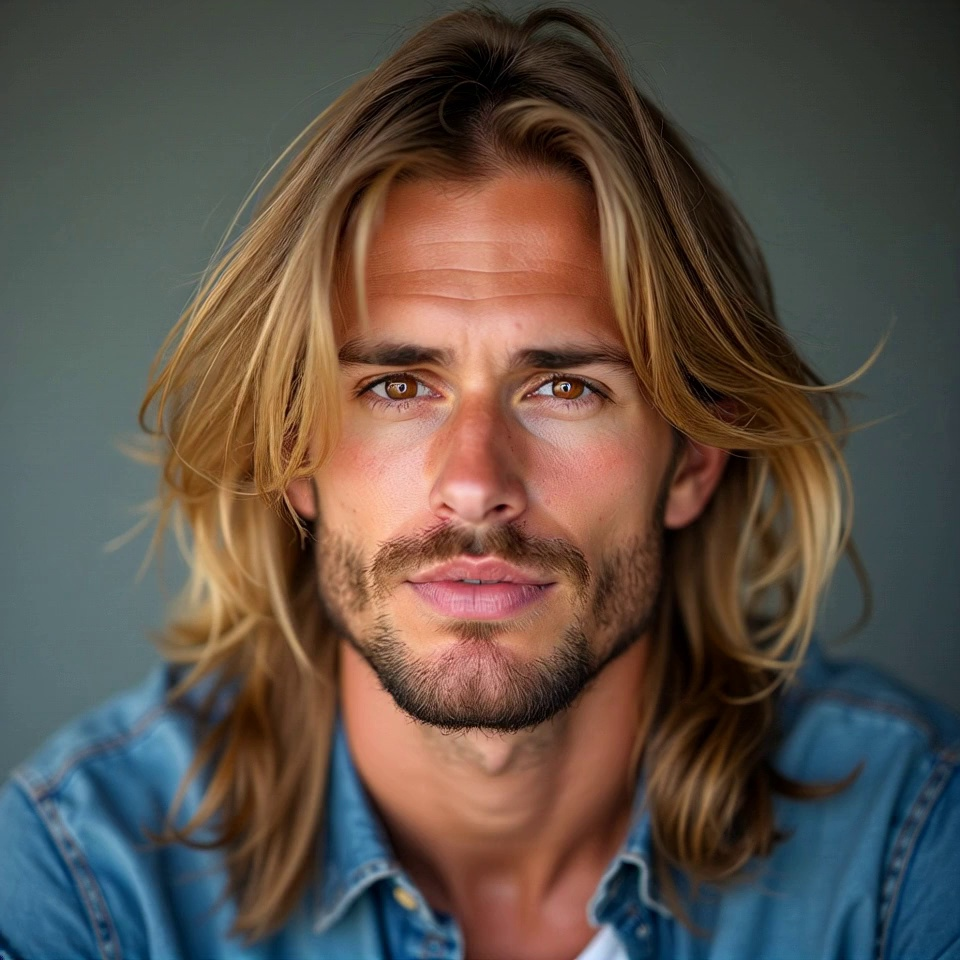

In [22]:
from IPython.display import Image as IPImage, display
parts = open(DATA_PATH).readline().strip().split()
img_path, audio_path = parts[0], parts[1]
print(f'Image : {img_path}\nAudio : {audio_path}')
if os.path.exists(img_path):
    display(IPImage(filename=img_path, width=300))

## ⚙️ Step 10 — Configure Inference

In [23]:
CONFIG_PATH   = f'{REPO_DIR}/configs/avatarforcing.yaml'
OUTPUT_FOLDER = f'{REPO_DIR}/outputs'

# (NUM_OUTPUT_FRAMES - 1) must be divisible by 4
# Valid: 21 (0.8s), 81 (3.2s), 125 (4.9s), 225 (8.9s)
NUM_OUTPUT_FRAMES = 225
SEED        = 42
NUM_SAMPLES = 1
USE_EMA     = False

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
assert (NUM_OUTPUT_FRAMES - 1) % 4 == 0, '(NUM_OUTPUT_FRAMES-1) must be divisible by 4!'
print(f'✅ {NUM_OUTPUT_FRAMES} frames (~{(NUM_OUTPUT_FRAMES-1)/25:.1f}s @ 25 FPS)')

✅ 225 frames (~9.0s @ 25 FPS)


## 🚀 Step 11 — Run Inference

In [24]:
print('Installing omegaconf...')
run_in_env(
    'pip install omegaconf'
)
print('✅ omegaconf installed.')

Installing omegaconf...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install omegaconf
  Using cached antlr4-python3-runtime-4.9.3.tar.gz (117 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  DEPRECATION: Building 'antlr4-python3-runtime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'antlr4-python3-runtime'. Discussion can be found at https://github.com/pypa/pip/issues/6334


  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.3-py3-none-any.whl size=144591 sha256=09898ee83bc94b9aafa39a8a4e57bc29fa1df742d5c37fa1680f95ddb9c7b34c
  Stored in directory: /root/.cache/pip/wheels/12/93/dd/1f6a127edc45659556564c5730f6d4e300888f4bca2d4c5a88
Successfully built antlr4-python3-runtime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [omegaconf]
✅ omegaconf installed.


In [25]:
print('Installing peft...')
run_in_env(
    'pip install peft'
)
print('✅ peft installed.')

Installing peft...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install peft
  Using cached psutil-7.2.2-cp36-abi3-manylinux2010_x86_64.manylinux_2_12_x86_64.manylinux_2_28_x86_64.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 22.3 MB/s  0:00:00
Using cached psutil-7.2.2-cp36-abi3-manylinux2010_x86_64.manylinux_2_12_x86_64.manylinux_2_28_x86_64.whl (155 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 141.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 170.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.6/793.6 kB 161.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [peft]6/7 [peft]formers]


✅ peft installed.


In [26]:
run_in_env('pip install easydict')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install easydict
  Using cached easydict-1.13-py3-none-any.whl.metadata (4.2 kB)


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install easydict', returncode=0)

In [27]:
run_in_env('pip install diffusers')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install diffusers
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 86.7 MB/s  0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [diffusers]/7 [diffusers]metadata]


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install diffusers', returncode=0)

In [28]:
run_in_env('pip install ftfy')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install ftfy
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ftfy]


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install ftfy', returncode=0)

In [29]:
run_in_env('pip install lmdb')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install lmdb


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install lmdb', returncode=0)

In [30]:
run_in_env('pip install pandas')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install pandas
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [pandas]2m4/5 [pandas]


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install pandas', returncode=0)

In [31]:
run_in_env('pip install opencv-python')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install opencv-python
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 181.8 MB/s  0:00:00m0:00:0100:01


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install opencv-python', returncode=0)

In [32]:
run_in_env('pip install decord')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install decord
  Using cached decord-0.6.0-py3-none-manylinux2010_x86_64.whl.metadata (422 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 127.1 MB/s  0:00:00


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install decord', returncode=0)

In [33]:
print('Installing soundfile...')
run_in_env(
    'pip install soundfile'
)
print('✅ soundfile installed.')

Installing soundfile...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install soundfile
  Using cached cffi-2.0.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [soundfile]
✅ soundfile installed.


In [ ]:
print('Installing system dependency libsndfile...')
run_in_env(
    'conda install -y -c conda-forge libsndfile'
)
print('✅ libsndfile installed.')

In [34]:
print('Checking torch ecosystem versions...')
run_in_env(
    'python -c "import torch, torchvision, torchaudio; '
    'print(f\'torch: {torch.__version__}\'); '
    'print(f\'torchvision: {torchvision.__version__}\'); '
    'print(f\'torchaudio: {torchaudio.__version__}\')"'
)

Checking torch ecosystem versions...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python -c "import torch, torchvision, torchaudio; print(f'torch: {torch.__version__}'); print(f'torchvision: {torchvision.__version__}'); print(f'torchaudio: {torchaudio.__version__}')"
torch: 2.6.0+cu126
torchvision: 0.21.0+cu126
torchaudio: 2.6.0+cu126


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python -c "import torch, torchvision, torchaudio; print(f\'torch: {torch.__version__}\'); print(f\'torchvision: {torchvision.__version__}\'); print(f\'torchaudio: {torchaudio.__version__}\')"', returncode=0)

In [35]:
print('Checking installed packages...')
run_in_env(
    'pip list | grep -E "torch|audio|vision"'
)

Checking installed packages...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip list | grep -E "torch|audio|vision"
pytorch-lightning        2.6.1
torch                    2.6.0+cu126
torchaudio               2.6.0+cu126
torchmetrics             1.9.0
torchvision              0.21.0+cu126


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip list | grep -E "torch|audio|vision"', returncode=0)

In [36]:
wav2vec_path = '/workspace/AvatarForcing/wan/models/wav2vec.py'

with open(wav2vec_path, 'r') as f:
    src = f.read()

# Remove both occurrences of the forbidden line
fixed = src.replace('        self.config.output_attentions = True\n', '')

if fixed == src:
    print('⚠️  Line not found — check file manually')
else:
    with open(wav2vec_path, 'w') as f:
        f.write(fixed)
    count = src.count('        self.config.output_attentions = True')
    print(f'✅ Removed {count} occurrence(s) of self.config.output_attentions = True')
    print('   File saved. Re-run inference now.')

✅ Removed 2 occurrence(s) of self.config.output_attentions = True
   File saved. Re-run inference now.


In [42]:
run_in_env('pip install av')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install av
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 117.4 MB/s  0:00:00 eta 0:00:01


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install av', returncode=0)

In [43]:
ema_flag = '--use_ema' if USE_EMA else ''
cmd = (
    f'python {REPO_DIR}/inference.py '
    f'--config_path {CONFIG_PATH} '
    f'--output_folder {OUTPUT_FOLDER} '
    f'--checkpoint_path {CHECKPOINT_PATH} '
    f'--data_path {DATA_PATH} '
    f'--num_output_frames {NUM_OUTPUT_FRAMES} '
    f'--seed {SEED} --num_samples {NUM_SAMPLES} '
    f'--i2v {ema_flag}'
)
print('Command:', cmd)
run_in_env(cmd)

Command: python /workspace/AvatarForcing/inference.py --config_path /workspace/AvatarForcing/configs/avatarforcing.yaml --output_folder /workspace/AvatarForcing/outputs --checkpoint_path /workspace/AvatarForcing/checkpoints/model.pt --data_path /workspace/AvatarForcing/example/promot.txt --num_output_frames 225 --seed 42 --num_samples 1 --i2v 
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python /workspace/AvatarForcing/inference.py --config_path /workspace/AvatarForcing/configs/avatarforcing.yaml --output_folder /workspace/AvatarForcing/outputs --checkpoint_path /workspace/AvatarForcing/checkpoints/model.pt --data_path /workspace/AvatarForcing/example/promot.txt --num_output_frames 225 --seed 42 --num_samples 1 --i2v 
KV inference with 4 frames per block
Use LoRA: rank=128, alpha=64.0
Number of prompts: 1


Loading weights: 100%|██████████| 210/210 [00:00<00:00, 6941.80it/s]
[transformers] Wav2VecModel LOAD REPORT from: ./wan_models/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
0it [00:00, ?it/s][transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enabl

CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python /workspace/AvatarForcing/inference.py --config_path /workspace/AvatarForcing/configs/avatarforcing.yaml --output_folder /workspace/AvatarForcing/outputs --checkpoint_path /workspace/AvatarForcing/checkpoints/model.pt --data_path /workspace/AvatarForcing/example/promot.txt --num_output_frames 225 --seed 42 --num_samples 1 --i2v ', returncode=0)

In [38]:
attn_path = '/workspace/AvatarForcing/wan/modules/attention.py'

new_src = '''# Copyright 2024-2025 The Alibaba Wan Team Authors. All rights reserved.
# flash-attn replaced with torch SDPA for RTX 5090 (sm_120) compatibility
import warnings
import torch
import torch.nn.functional as F

FLASH_ATTN_3_AVAILABLE = False
FLASH_ATTN_2_AVAILABLE = False

__all__ = [
    'flash_attention',
    'attention',
]

def flash_attention(
    q, k, v,
    q_lens=None,
    k_lens=None,
    dropout_p=0.,
    softmax_scale=None,
    q_scale=None,
    causal=False,
    window_size=(-1, -1),
    deterministic=False,
    dtype=torch.bfloat16,
    version=None,
):
    """
    Drop-in replacement using PyTorch SDPA (RTX 5090 / sm_120 compatible).
    q: [B, Lq, Nq, C1]
    k: [B, Lk, Nk, C1]
    v: [B, Lk, Nk, C2]
    """
    half_dtypes = (torch.float16, torch.bfloat16)
    assert dtype in half_dtypes
    b, lq, lk, out_dtype = q.size(0), q.size(1), k.size(1), q.dtype

    def half(x):
        return x if x.dtype in half_dtypes else x.to(dtype)

    # Handle variable-length sequences by padding/masking
    if q_lens is not None or k_lens is not None:
        warnings.warn(
            'Padding mask is disabled when using scaled_dot_product_attention. '
            'It can have a significant impact on performance.'
        )

    if q_scale is not None:
        q = q * q_scale

    # q/k/v: [B, L, N, C] -> [B, N, L, C] for SDPA
    q = half(q).transpose(1, 2)
    k = half(k).transpose(1, 2)
    v = half(v).transpose(1, 2)

    scale = softmax_scale if softmax_scale is not None else q.shape[-1] ** -0.5

    out = F.scaled_dot_product_attention(
        q, k, v,
        scale=scale,
        dropout_p=dropout_p if torch.is_grad_enabled() else 0.0,
        is_causal=causal,
    )
    # [B, N, L, C] -> [B, L, N, C]
    return out.transpose(1, 2).to(out_dtype)


def attention(
    q, k, v,
    q_lens=None,
    k_lens=None,
    dropout_p=0.,
    softmax_scale=None,
    q_scale=None,
    causal=False,
    window_size=(-1, -1),
    deterministic=False,
    dtype=torch.bfloat16,
    fa_version=None,
):
    return flash_attention(
        q=q, k=k, v=v,
        q_lens=q_lens, k_lens=k_lens,
        dropout_p=dropout_p,
        softmax_scale=softmax_scale,
        q_scale=q_scale,
        causal=causal,
        window_size=window_size,
        deterministic=deterministic,
        dtype=dtype,
        version=fa_version,
    )
'''

with open(attn_path, 'w') as f:
    f.write(new_src)
print('✅ attention.py fully rewritten — both flash_attention and attention use SDPA.')

✅ attention.py fully rewritten — both flash_attention and attention use SDPA.


In [39]:
# Verify both exports work
verify = '/tmp/verify_attn.py'
with open(verify, 'w') as f:
    f.write("""
import sys
sys.path.insert(0, '/workspace/AvatarForcing')
from wan.modules.attention import flash_attention, attention
import torch
q = torch.randn(1, 16, 8, 64).cuda().bfloat16()
out1 = flash_attention(q, q, q)
out2 = attention(q, q, q)
print('flash_attention output:', out1.shape)
print('attention output:', out2.shape)
print('Both OK — no flash-attn needed.')
""")
run_in_env(f'python {verify}')

>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python /tmp/verify_attn.py
flash_attention output: torch.Size([1, 16, 8, 64])
attention output: torch.Size([1, 16, 8, 64])
Both OK — no flash-attn needed.


CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python /tmp/verify_attn.py', returncode=0)

In [ ]:
#this only for 5090 GPU

In [42]:
# 🔧 FIX — Replace torch 2.6.0 with nightly that supports RTX 5090 (sm_120)
print('Uninstalling old torch stack...')
run_in_env('pip uninstall -y torch torchvision torchaudio')

print('Installing PyTorch nightly cu128 (sm_120 / Blackwell support)...')
run_in_env(
    'pip install --pre torch torchvision torchaudio '
    '--index-url https://download.pytorch.org/whl/nightly/cu128'
)
print('✅ Done. Verifying...')
run_in_env(
    'python -c "'
    'import torch; '
    'print(torch.__version__); '
    'print(torch.cuda.get_device_capability()); '
    'x = torch.tensor([1.0]).cuda(); '
    'print(x * 2, \'GPU OK\')'
    '"'
)

Uninstalling old torch stack...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip uninstall -y torch torchvision torchaudio
Found existing installation: torch 2.6.0+cu126
Uninstalling torch-2.6.0+cu126:
  Successfully uninstalled torch-2.6.0+cu126
Found existing installation: torchvision 0.21.0+cu126
Uninstalling torchvision-0.21.0+cu126:
  Successfully uninstalled torchvision-0.21.0+cu126
Found existing installation: torchaudio 2.6.0+cu126
Uninstalling torchaudio-2.6.0+cu126:
  Successfully uninstalled torchaudio-2.6.0+cu126
Installing PyTorch nightly cu128 (sm_120 / Blackwell support)...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128
Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 47.2 MB/s  0:00:13:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CompletedProcess(args='/root/miniconda3/bin/conda run -n avatarforcing --no-capture-output python -c "import torch; print(torch.__version__); print(torch.cuda.get_device_capability()); x = torch.tensor([1.0]).cuda(); print(x * 2, \'GPU OK\')"', returncode=0)

In [44]:
# 🔧 FIX — Rebuild flash-attn against torch 2.12.0 nightly
print('Uninstalling old flash-attn...')
run_in_env('pip uninstall -y flash-attn')

print('Building flash-attn from source against new torch (takes 10-20 min)...')
run_in_env(
    'pip install flash-attn --no-build-isolation',
)
print('✅ flash-attn rebuilt.')

Uninstalling old flash-attn...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip uninstall -y flash-attn
Found existing installation: flash_attn 2.8.3
Uninstalling flash_attn-2.8.3:
  Successfully uninstalled flash_attn-2.8.3
Building flash-attn from source against new torch (takes 10-20 min)...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip install flash-attn --no-build-isolation
  Using cached flash_attn-2.8.3-cp310-cp310-linux_x86_64.whl
✅ flash-attn rebuilt.


In [ ]:
# 🔧 FIX — Force true source rebuild of flash-attn (no cache)
print('Step 1: Uninstall flash-attn...')
run_in_env('pip uninstall -y flash-attn')

print('Step 2: Clear pip cache to prevent stale wheel reuse...')
run_in_env('pip cache purge')

print('Step 3: Remove any leftover compiled artifacts...')
run_in_env('rm -rf /tmp/pip-build-* /root/.cache/pip/wheels/*/flash_attn*')

print('Step 4: Building from source — this will take 10-20 min, do not interrupt...')
run_in_env(
    'FLASH_ATTENTION_FORCE_BUILD=1 '
    'MAX_JOBS=4 '
    'pip install flash-attn==2.8.3 '
    '--no-build-isolation '
    '--no-cache-dir '
    '--verbose '
    '2>&1 | tail -20'
)
print('✅ flash-attn source build complete.')

Step 1: Uninstall flash-attn...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip uninstall -y flash-attn
Found existing installation: flash_attn 2.8.3
Uninstalling flash_attn-2.8.3:
  Successfully uninstalled flash_attn-2.8.3
Step 2: Clear pip cache to prevent stale wheel reuse...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output pip cache purge
Files removed: 652 (2552.0 MB)
Step 3: Remove any leftover compiled artifacts...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output rm -rf /tmp/pip-build-* /root/.cache/pip/wheels/*/flash_attn*
Step 4: Building from source — this will take 10-20 min, do not interrupt...
>>> /root/miniconda3/bin/conda run -n avatarforcing --no-capture-output FLASH_ATTENTION_FORCE_BUILD=1 MAX_JOBS=4 pip install flash-attn==2.8.3 --no-build-isolation --no-cache-dir --verbose 2>&1 | tail -20


In [ ]:
run_in_env(
    'python -c "'
    'import flash_attn; '
    'print(\"flash_attn:\", flash_attn.__version__); '
    'from flash_attn.flash_attn_interface import flash_attn_func; '
    'print(\"flash_attn import OK\")'
    '"'
)

## 🎥 Step 12 — Display Output Video

In [ ]:
from IPython.display import Video, display
videos = sorted(glob.glob(f'{OUTPUT_FOLDER}/*.mp4'), key=os.path.getmtime, reverse=True)
if videos:
    print(f'Latest: {videos[0]}  ({os.path.getsize(videos[0])/1e6:.1f} MB)')
    display(Video(videos[0], embed=True, width=832, height=480))
    for v in videos:
        print(f'  {v}')
else:
    print('⚠️  No output videos found.')

## 🩺 Troubleshooting

| Issue | Fix |
|---|---|
| `conda: not found` | Step 1 auto-installs Miniconda |
| `CondaToSNonInteractiveError` | Step 3a accepts TOS |
| `torch==2.5.1+cu121 not found` | Fixed: torch removed from yml; installed via PyTorch index in Step 5 |
| `flash-attn build takes hours` | Fixed: pre-built wheel installed in Step 5d (seconds) |
| `CUDA not available` | Step 5a installs cu126 wheels |
| OOM error | Reduce `NUM_OUTPUT_FRAMES` to 81 |
| `(N-1) % 4 != 0` | Use: 21, 25, 81, 125, 225 |
| No `.pt` checkpoint | Re-run Step 7 download cell |